363


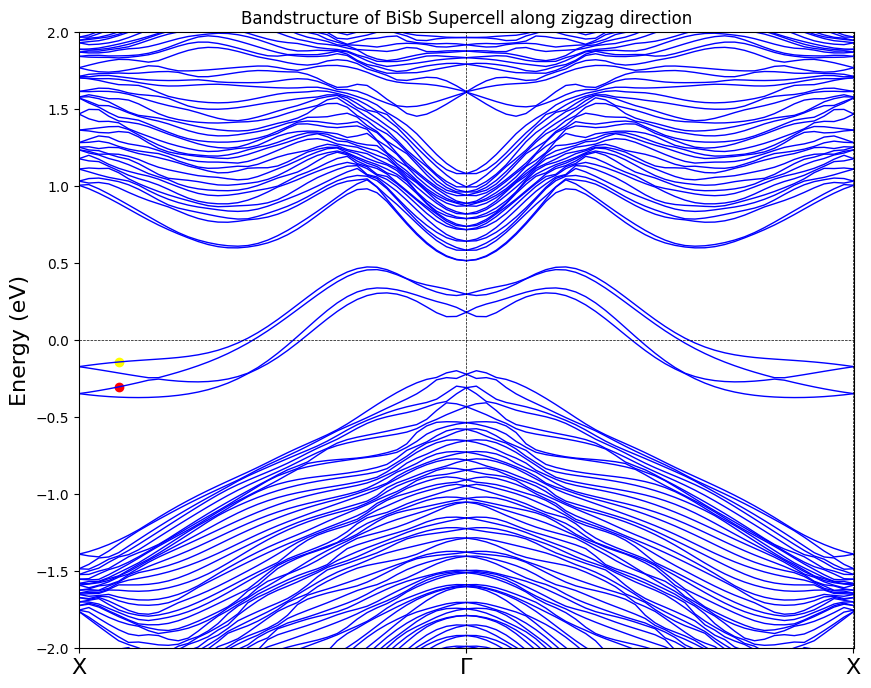

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.737,1.474]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=1)


plt.scatter(k[4],bands[4,299],color='red')

plt.scatter(k[4],bands[4,301],color='yellow')

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of BiSb Supercell along zigzag direction")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
plt.savefig("nanoribbon_bandstructure.png", dpi=300, bbox_inches='tight')
plt.show()

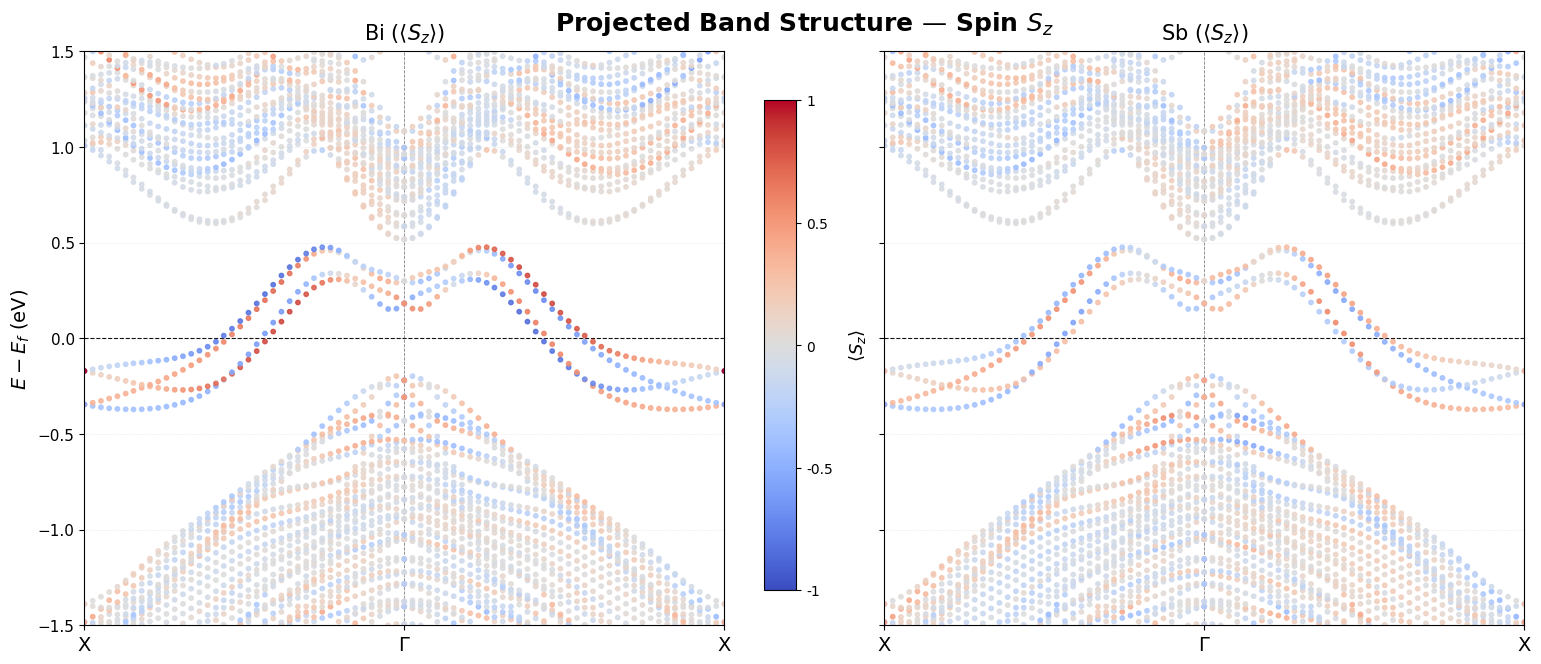

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load Data ---
def load_band_data(filepath):
    return pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, skiprows=2)

data_bi = load_band_data("PBAND_Bi_SOC_SZ.dat")
data_sb = load_band_data("PBAND_Sb_SOC_SZ.dat")

k = data_bi[0].to_numpy()
e = data_bi[1].to_numpy()

# --- High-symmetry k-points and labels ---
k_points = [0,0.737,1.475]  
k_labels = ['X', r'$\Gamma$', 'X']

# --- Energy mask: apply BEFORE normalization ---
E_MASK_MIN, E_MASK_MAX = -1.5, 1.5   # adjust to taste

e_mask = (e >= E_MASK_MIN) & (e <= E_MASK_MAX)

spin_bi = data_bi[11].to_numpy()
spin_sb = data_sb[11].to_numpy()

# Compute absmax only within the energy window
global_absmax = max(np.abs(spin_bi[e_mask]).max(), np.abs(spin_sb[e_mask]).max())

spin_bi_norm = spin_bi[e_mask] / global_absmax
spin_sb_norm = spin_sb[e_mask] / global_absmax

k_masked = k[e_mask]
e_masked = e[e_mask]

# --- Shared norm and colormap ---
CMAP = 'coolwarm'
shared_norm = Normalize(vmin=-1, vmax=1)

# --- Plot ---
TITLES = [r'Bi ($\langle S_z \rangle$)', r'Sb ($\langle S_z \rangle$)']
spins  = [spin_bi_norm, spin_sb_norm]

fig = plt.figure(figsize=(16, 7))
fig.suptitle(r"Projected Band Structure — Spin $S_z$", fontsize=18, fontweight='bold')

ax_left  = fig.add_axes([0.05, 0.10, 0.40, 0.82])
ax_right = fig.add_axes([0.55, 0.10, 0.40, 0.82])
ax_cbar  = fig.add_axes([0.475, 0.15, 0.02, 0.70])

axes = [ax_left, ax_right]

for ax, spin, title in zip(axes, spins, TITLES):
    ax.scatter(k_masked, e_masked, c=spin, cmap=CMAP, s=10, norm=shared_norm, alpha=0.85, rasterized=True)

    for xv in k_points[1:-1]:
        ax.axvline(xv, ls='--', lw=0.6, color='gray', zorder=0)

    ax.axhline(0, ls='--', lw=0.8, color='black', zorder=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(k_points[0], k_points[-1])
    ax.set_xticks(k_points)
    ax.set_xticklabels(k_labels, fontsize=14)
    ax.set_title(title, fontsize=15, pad=8)
    ax.tick_params(axis='y', labelsize=11)

ax_left.set_ylabel(r'$E - E_f$ (eV)', fontsize=14)
ax_right.set_yticklabels([])

# --- Centered colorbar ---
sm = ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\langle S_z \rangle$', fontsize=13, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=10)

plt.savefig("spin_polarized_nanoribbon_bands.png", dpi=300, bbox_inches='tight')

plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_18872\3792140337.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_18872\3792140337.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


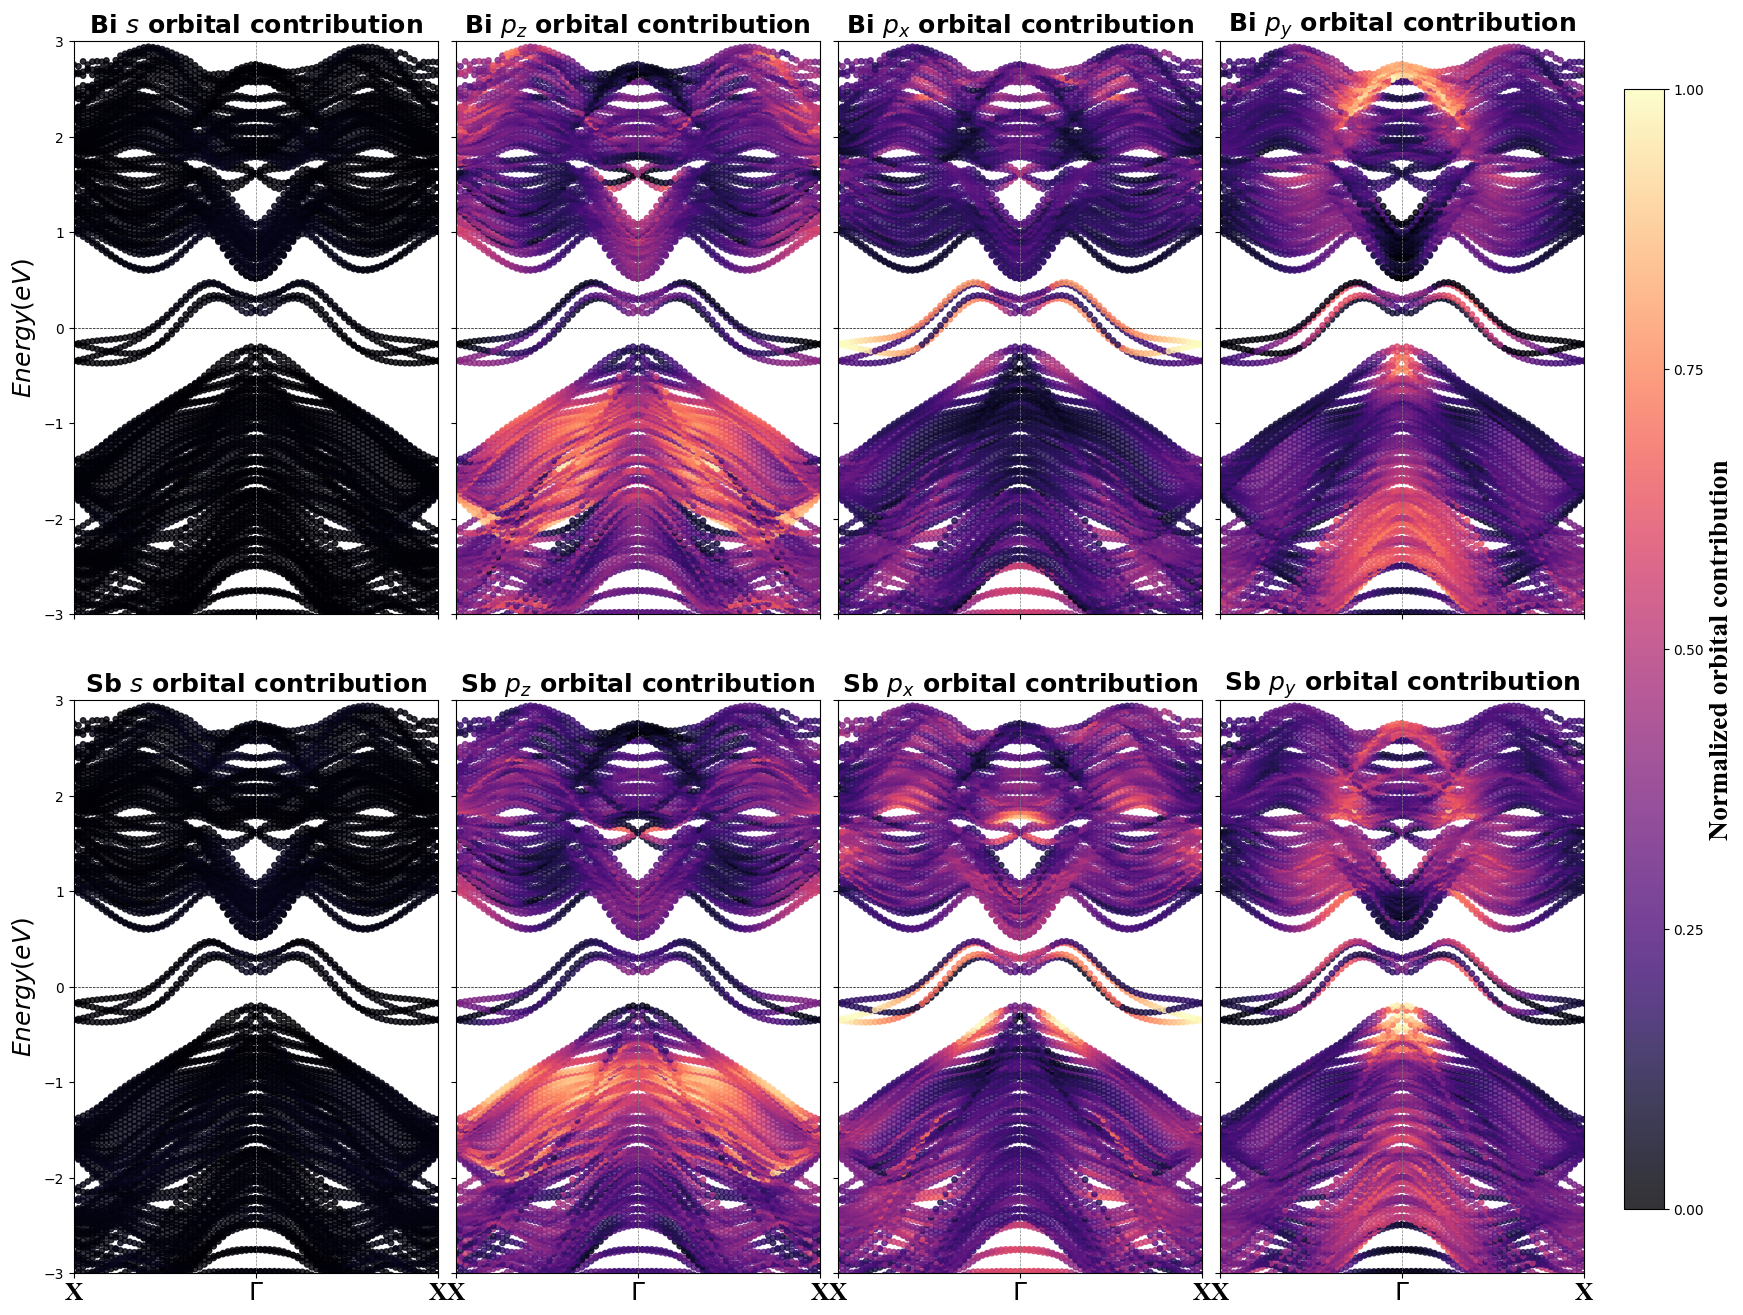

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[2], bi_norms[3], bi_norms[1],
            sb_norms[0],sb_norms[2], sb_norms[3], sb_norms[1]] 

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$',  'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap     = 'magma'

high_symmetry_points = [0, max(k)/2 , max(k)]
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

fig, axes = plt.subplots(2, 4, figsize=(20, 16), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")

    # y-axis label only on left column
    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$',fontsize=18,fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution',fontsize=20,fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)
plt.savefig("orbital_composed_bands.png", dpi=150, bbox_inches="tight")
plt.show()